In [1]:
import shap # biblioteca para interpretar previsões do modelo
import numpy as np # biblioteca para cálculos numéricos
from sklearn.datasets import load_breast_cancer # importa o conjunto de dados
from sklearn.model_selection import train_test_split # importa função para dividir dados
from sklearn.svm import LinearSVC # importa o algoritmo de classificacao

In [4]:
data = load_breast_cancer()
X, y = data["data"], data["target"] # separa os atributos do objetivo

In [6]:
data["target_names"] # mostra o nome das categorias

array(['malignant', 'benign'], dtype='<U9')

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) # separa 20% dos dados

In [14]:
clf = LinearSVC() # inicializa o modelo
clf.fit(X_train, y_train) #treina o modelo

LinearSVC()

In [15]:
clf.score(X_test, y_test) #precisao do modelo

0.956140350877193

In [17]:
clf.predict([X_test[0]])

array([1])

In [19]:
explainer = shap.KernelExplainer(clf.predict,shap.kmeans(X_train,10)) # cria o SHAP usando o KernelExplainer

In [21]:
shap_values = explainer.shap_values(X_test) # calcula o impacto de cada característica na previsão

  0%|          | 0/114 [00:00<?, ?it/s]

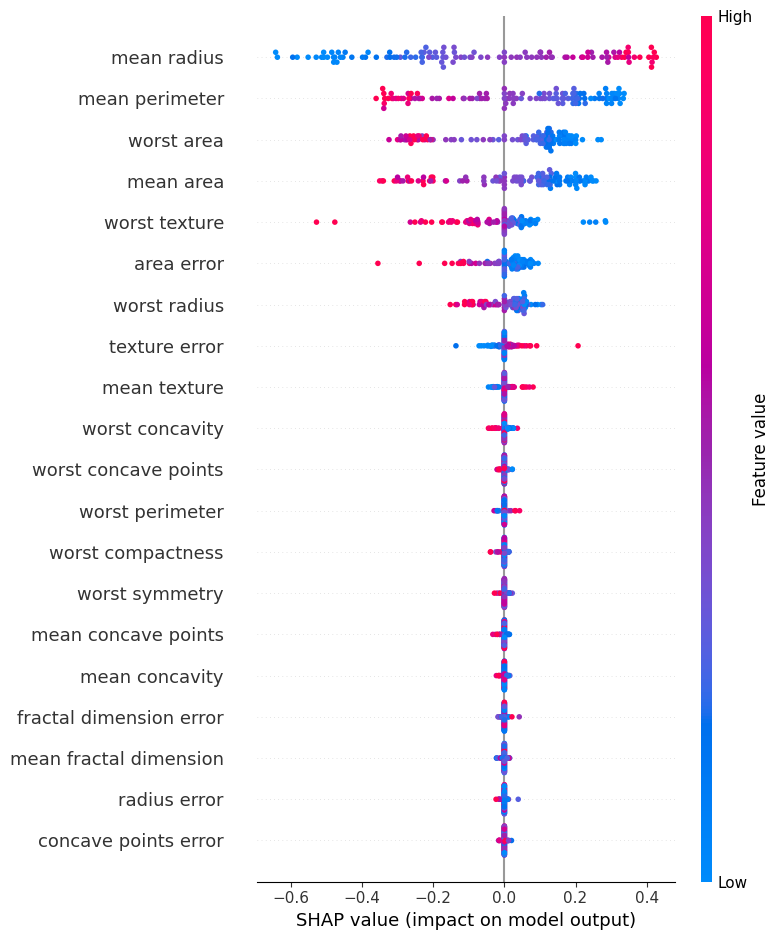

In [23]:
shap.summary_plot(shap_values, X_test, feature_names = data["feature_names"]) # gera o grafic

In [25]:
shap.initjs() # inicializa a biblioteca javascript
shap.force_plot(explainer.expected_value, shap_values[0], X_test[0], feature_names = data["feature_names"]) # cria o grafico

In [27]:
mean_abs_shap_values = np.abs(shap_values).mean(axis = 0) # calcula a merdia

In [28]:
feature_names = data["feature_names"] # armazena o nome das colunas
feature_importance = zip(feature_names, mean_abs_shap_values) # combina nomes com seus respectivos valores

In [29]:
sorted_feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse = True) # ordena os resultados

In [30]:
for feature, importance in sorted_feature_importance:
    print(feature, ":", importance) # exibe o nome do atributo

mean radius : 0.27376995349934297
mean perimeter : 0.19130572153244813
worst area : 0.15388180650591157
mean area : 0.149470580166244
worst texture : 0.0778891839594442
area error : 0.04809920283296572
worst radius : 0.047558062521661566
texture error : 0.018236329150813854
mean texture : 0.009092473172961135
worst concavity : 0.006360712338253867
worst concave points : 0.0026278622763252265
worst perimeter : 0.002473201671033855
worst compactness : 0.0024165994572954578
worst symmetry : 0.001984707936182351
mean concave points : 0.0019558786797146746
mean concavity : 0.0018290176837800227
fractal dimension error : 0.001565807752671431
mean fractal dimension : 0.0015578671638117342
radius error : 0.0014799716587603525
concave points error : 0.001382758832138399
worst fractal dimension : 0.001209918566959276
perimeter error : 0.0010746628023296369
worst smoothness : 0.0010376456964743734
mean smoothness : 0.00102581363309849
compactness error : 0.001018754140741565
mean compactness : 0.